## Task 2 — Data Preparation

Follow the exact data splitting procedure below. Deviating from this workflow will result in mark deductions.

* 1	Load both diabetic_data.csv and IDS_mapping.csv. Apply the ID mappings to decode categorical columns where appropriate (admission_type_id, discharge_disposition_id, admission_source_id).
* 2	Perform any initial data cleaning required (handling missing values indicated by '?', removing duplicates, correcting data types).
* 3	Sample exactly 5% of the full cleaned dataset using stratified sampling proportional to the target variable readmitted. Save this sample as unseen_data.csv — this file simulates the data Gruve's graders will use to test your model. Do NOT use this data during training or evaluation.
* 4	From the remaining 95% of data, split into: 80% Training Set and 20% Hold-Out Test Set, again using stratified sampling on readmitted.
* 5	The 20% hold-out test set is what you will use to evaluate and report your model's performance to graders.

* Data Split Summary   
    * Full Dataset (100%)  →  Unseen Sample (5%, stratified)  +  Working Data (95%)
    * Working Data (95%)  →  Training Set (80%)  +  Hold-Out Test Set (20%)

In [33]:
# Core imports and path settings
from __future__ import annotations

from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'src' else Path.cwd().resolve()
# Raw given data path
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
RAW_DATA_PATH = RAW_DIR / 'diabetic_data.csv'
IDS_MAPPING_PATH = RAW_DIR / 'IDS_mapping.csv'

# Preprocessed data path 
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
CLEANED_DATA_PATH = PROCESSED_DIR / 'cleaned_data.csv'
TRAIN_PATH = PROCESSED_DIR / 'train.csv'
TEST_PATH = PROCESSED_DIR / 'test.csv'
UNSEEN_PROCESSED_PATH = PROCESSED_DIR / 'unseen_data.csv'

# unseen_data.csv for Gruve's graders 
TEST_DIR = PROJECT_ROOT / 'data' / 'test'
UNSEEN_TEST_PATH = TEST_DIR / 'unseen_data.csv'

for directory in [PROCESSED_DIR, TEST_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET_COL = 'readmitted' # Target column

### 2.1 Load Data and Apply ID Mapping

In [5]:
def load_id_mappings(ids_path: Path) -> Dict[str, Dict[int, str]]:
    """Parse IDS_mapping.csv into three lookup dictionaries.

    IDS_mapping.csv has section-style rows where the first column switches
    between: admission_type_id, discharge_disposition_id, admission_source_id.
    """
    sections = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
    mapping_df = pd.read_csv(ids_path, dtype=str)
    mapping_df.columns = ['raw_key', 'description']

    mappings = {section: {} for section in sections}
    current_section = sections[0]

    for row in mapping_df.itertuples(index=False):
        key = '' if pd.isna(row.raw_key) else str(row.raw_key).strip()
        desc = '' if pd.isna(row.description) else str(row.description).strip()

        if key in sections:
            current_section = key
            continue

        if current_section is None or key == '':
            continue

        try:
            key_int = int(float(key))
        except ValueError:
            continue

        mappings[current_section][key_int] = desc if desc else 'Unknown'

    return mappings


def apply_id_mapping(df: pd.DataFrame, mappings: Dict[str, Dict[int, str]]) -> pd.DataFrame:
    """Apply categorical ID mapping and preserve original ids in *_id_raw columns."""
    mapped = df.copy()

    for column, lookup in mappings.items():
        if column not in mapped.columns:
            continue

        # Preserve raw numeric id for traceability / audit
        mapped[f'{column}_raw'] = mapped[column]
        mapped[column] = mapped[column].map(lookup).fillna('Unknown')

    return mapped


raw_df = pd.read_csv(RAW_DATA_PATH)
id_mappings = load_id_mappings(IDS_MAPPING_PATH)
mapped_df = apply_id_mapping(raw_df, id_mappings)

print('Raw shape:', raw_df.shape)
print('Mapped shape:', mapped_df.shape)
print('Mapping sizes:', {k: len(v) for k, v in id_mappings.items()})
mapped_df[['admission_type_id', 'discharge_disposition_id', 'admission_source_id']].head()

Raw shape: (101766, 50)
Mapped shape: (101766, 53)
Mapping sizes: {'admission_type_id': 8, 'discharge_disposition_id': 30, 'admission_source_id': 25}


,admission_type_id,discharge_disposition_id,admission_source_id
0,Unknown,Not Mapped,Physician Referral
1,Emergency,Discharged to home,Emergency Room
2,Emergency,Discharged to home,Emergency Room
3,Emergency,Discharged to home,Emergency Room
4,Emergency,Discharged to home,Emergency Room


### 2.2 Initial Cleaning (`?`, duplicates, dtypes)

Correcting data types based on given variable descriptions

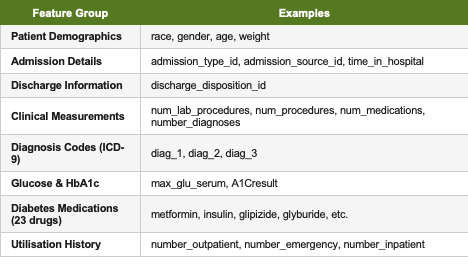

In [ ]:
# Initial data cleaning with explicit dtype inspection
cleaned_df = mapped_df.copy()
cleaned_df.columns = [str(c).strip() for c in cleaned_df.columns]

# 2.2.1. Replace '?' placeholders with NaN
placeholder_counts = (cleaned_df == '?').sum().sort_values(ascending=False)
print("Placeholder counts:")
print(placeholder_counts[placeholder_counts > 0])
cleaned_df = cleaned_df.replace('?', np.nan)

Placeholder counts:
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [ ]:
# 2.2.2. Removing duplicateseck 
duplicate_rows = int(cleaned_df.duplicated().sum())
print("Duplicated rows:")
print("The number of duplicated rows", duplicate_rows)
cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

# Check data type
print("\nDataFrame info")
cleaned_df.info(verbose=True, show_counts=True)

Duplicated rows:
The number of duplicated rows 0

DataFrame info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   encounter_id                  101766 non-null  int64 
 1   patient_nbr                   101766 non-null  int64 
 2   race                          99493 non-null   object
 3   gender                        101766 non-null  object
 4   age                           101766 non-null  object
 5   weight                        3197 non-null    object
 6   admission_type_id             101766 non-null  object
 7   discharge_disposition_id      101766 non-null  object
 8   admission_source_id           101766 non-null  object
 9   time_in_hospital              101766 non-null  int64 
 10  payer_code                    61510 non-null   object
 11  medical_specialty             51817 non-null   objec

In [ ]:
# 2.2.3. Correct data types based on actual non-null values inspected from the CSV
# Numeric ID/raw/count columns that should remain numeric
int_cols = [
    "encounter_id",
    "patient_nbr",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "admission_type_id_raw",
    "discharge_disposition_id_raw",
    "admission_source_id_raw",
]

for col in int_cols:
    cleaned_df[col] = pd.to_numeric(cleaned_df[col], errors="raise").astype("int64")

# Diagnosis codes should stay as strings
# because values include ICD codes like '250.83', 'V27', 'E...' etc.
diag_cols = ["diag_1", "diag_2", "diag_3"]
for col in diag_cols:
    cleaned_df[col] = cleaned_df[col].astype("string")

# Ordinal categorical columns
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]
cleaned_df["age"] = pd.Categorical(
    cleaned_df["age"],
    categories=age_order,
    ordered=True
)

# print(sorted(cleaned_df["weight"].dropna().unique())) 
# # ['>200', '[0-25)', '[100-125)', '[125-150)', '[150-175)', '[175-200)', '[25-50)', '[50-75)', '[75-100)']
weight_order = [
    "[0-25)", "[25-50)", "[50-75)", "[75-100)", "[100-125)",
    "[125-150)", "[150-175)", "[175-200)", ">200"
]
cleaned_df["weight"] = pd.Categorical(
    cleaned_df["weight"],
    categories=weight_order,
    ordered=True
)

# Mapped admission/discharge/source columns are decoded labels -> categorical
mapped_cat_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
]
for col in mapped_cat_cols:
    cleaned_df[col] = cleaned_df[col].astype("category")

# Binary / nominal categorical columns
nominal_cat_cols = [
    "race",
    "gender",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed",
    "readmitted",
]
for col in nominal_cat_cols:
    cleaned_df[col] = cleaned_df[col].astype("category")

# Medication status columns:
# actual values are categorical states such as No / Steady / Up / Down
medication_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide",
    "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]


for col in medication_cols:
    cleaned_df[col] = cleaned_df[col].astype("category")

# Optional: make gender explicitly nominal rather than ordered
cleaned_df["gender"] = cleaned_df["gender"].cat.remove_unused_categories()

# 4) Final check
print("\nCleaned DataFrame info")
cleaned_df.info(verbose=True, show_counts=True)

print("\nChanged dtypes:")
before_dtypes = mapped_df.dtypes.astype(str)
after_dtypes = cleaned_df.dtypes.astype(str)

dtype_compare = pd.DataFrame({
    "before": before_dtypes,
    "after": after_dtypes
})

print(dtype_compare[dtype_compare["before"] != dtype_compare["after"]])


Cleaned DataFrame info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   encounter_id                  101766 non-null  int64   
 1   patient_nbr                   101766 non-null  int64   
 2   race                          99493 non-null   category
 3   gender                        101766 non-null  category
 4   age                           101766 non-null  category
 5   weight                        3197 non-null    category
 6   admission_type_id             101766 non-null  category
 7   discharge_disposition_id      101766 non-null  category
 8   admission_source_id           101766 non-null  category
 9   time_in_hospital              101766 non-null  int64   
 10  payer_code                    61510 non-null   category
 11  medical_specialty             51817 non-null   category
 12  num_la

### 2.3 Exact 5% Stratified Unseen Split + 95% Working Split

In [34]:
# Sample 5% unseen data using stratified sampling
working_df, unseen_df = train_test_split(
    cleaned_df,
    test_size=0.05,
    random_state=RANDOM_STATE,
    stratify=cleaned_df[TARGET_COL],
)

# Split remaining 95% into 80% train and 20% hold-out test
train_df, test_df = train_test_split(
    working_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=working_df[TARGET_COL],
)

# Reset index
working_df = working_df.reset_index(drop=True)
unseen_df = unseen_df.reset_index(drop=True)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Save required files
unseen_df.to_csv(UNSEEN_PROCESSED_PATH, index=False)
unseen_df.to_csv(UNSEEN_TEST_PATH, index=False)
train_df.to_csv(TRAIN_PATH, index=False)
test_df.to_csv(TEST_PATH, index=False)

In [39]:
# Parquet for preserve dtype
cleaned_df.to_parquet(PROCESSED_DIR / "cleaned_data.parquet", index=False)
train_df.to_parquet(PROCESSED_DIR / "train.parquet", index=False)
test_df.to_parquet(PROCESSED_DIR / "test.parquet", index=False)
unseen_df.to_parquet(PROCESSED_DIR / "unseen_data.parquet", index=False)

In [37]:
print(unseen_df.shape)
print(train_df.shape)
print(test_df.shape)

(5089, 53)
(77341, 53)
(19336, 53)
